# **Start to Explore the Dataset**

In [51]:
import xarray as xr
import matplotlib.pyplot as plt
import dask
from dask.diagnostics import ProgressBar
import cartopy.crs as ccrs
import cartopy.feature as cfeature

solar_cf_path = "/home/563/ft3359/GC26-combined-solar-wind/data/raw/solar_cf"

# directory of netCDFs → open them all as one dataset
ds = xr.open_mfdataset(f"{solar_cf_path}/*.nc")
print(ds)

<xarray.Dataset> Size: 75GB
Dimensions:          (time: 736337, lat: 141, lon: 181)
Coordinates:
  * time             (time) datetime64[ns] 6MB 1940-01-01T07:00:00 ... 2023-1...
  * lat              (lat) float32 564B -10.0 -10.25 -10.5 ... -44.75 -45.0
  * lon              (lon) float32 724B 110.0 110.2 110.5 ... 154.5 154.8 155.0
Data variables:
    capacity_factor  (time, lat, lon) float32 75GB dask.array<chunksize=(8777, 141, 181), meta=np.ndarray>


# **Statistical Threshold**

In [15]:
var = 'capacity_factor'

# re-open
ds = xr.open_mfdataset(f"{solar_cf_path}/*.nc", chunks={'time': 24*30})
cf = ds[var]

# hourly -> daily mean
cf_daily = cf.resample(time='1D').mean()

# Group to Winter months: May – September
winter = cf_daily.sel(time=cf_daily.time.dt.month.isin([5, 6, 7, 8, 9]))

# materialise once
with ProgressBar():
    winter = winter.load()

mean_cf, std_cf = dask.compute(winter.mean('time'), winter.std('time'))
threshold = mean_cf - std_cf
drought_freq = (winter < threshold).mean('time')

# Print
print("mean drought frequency:", float(drought_freq.mean()))
print("mean CF:", float(mean_cf.mean()))
print("std CF:", float(std_cf.mean()))


mean drought frequency: 0.12445361968130962
mean CF: 0.16025076806545258
std CF: 0.0423460453748703


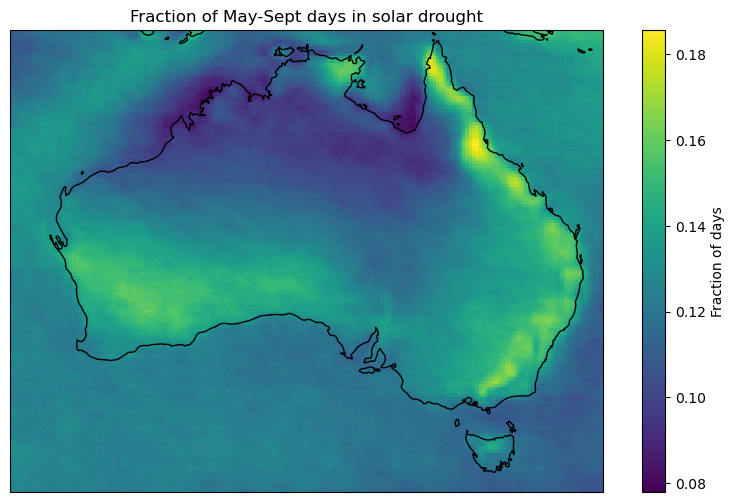

In [50]:
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

drought_freq.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='viridis',
    cbar_kwargs={'label': 'Fraction of days'}
)

ax.coastlines(resolution='50m')
ax.set_title('Fraction of May-Sept days in solar drought')
plt.show()

**above shows a map of the distribution shape**

# **Absolute Threshold**

In [40]:
threshold_abs = 0.10
drought_freq_abs = (winter < threshold_abs).mean('time')

print("mean drought frequency (absolute):", float(drought_freq_abs.mean()))

mean drought frequency (absolute): 0.20022526379690145


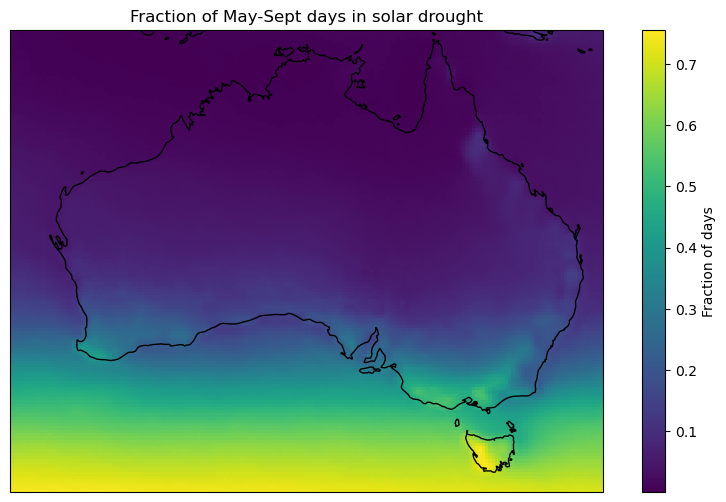

In [41]:
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

drought_freq_abs.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='viridis',
    cbar_kwargs={'label': 'Fraction of days'}
)

ax.coastlines(resolution='50m')
ax.set_title('Fraction of May-Sept days in solar drought')
plt.show()

**above shows a map of climatology**

# **Percentile Threshold**

In [42]:
threshold_pct = winter.quantile(0.10, dim='time') # 10th percentile per grid cell
drought_freq_pct = (winter < threshold_pct).mean('time')

print("mean drought frequency (percentile):", float(drought_freq_pct.mean()))

mean drought frequency (percentile): 0.10006222882814769


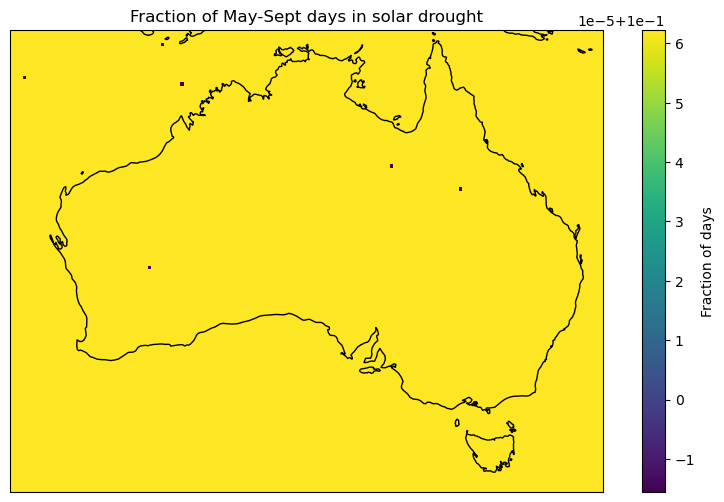

In [43]:
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

drought_freq_pct.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='viridis',
    cbar_kwargs={'label': 'Fraction of days'}
)

ax.coastlines(resolution='50m')
ax.set_title('Fraction of May-Sept days in solar drought')
plt.show()

**above shows nothing**